### [Causal Structure Learning with Bayesian Methods](https://medium.com/data-science-collective/the-starters-guide-to-causal-structure-learning-with-bayesian-methods-in-python-e3b90f49c99c)

> Starter's guide to effectively learn to determine causalities across variables.

In [1]:
!pip install --quiet bnlearn d3blocks markupsafe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.4/134.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

In [2]:
import os, sys, itertools
from IPython.display import display

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import bnlearn as bn
import pandas as pd
from scipy.stats import hypergeom

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.style.use("ggplot")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# Load predictive maintenance data set
pred_main_df = bn.import_example(data='predictive_maintenance')

# Print dataframe
display(pred_main_df)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
display(pred_main_df[['Machine failure','PWF']])

,Machine failure,PWF
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
9995,0,0
9996,0,0
9997,0,0
9998,0,0


In [5]:
# Total number of samples (population)
M = pred_main_df.shape[0]

# Number of successes in the population
n = sum(pred_main_df['Machine failure'] == 1)

# Sample size/number of draws
N = sum(pred_main_df['PWF'] == 1)

# Overlap between Power failure and machine failure
x = sum((pred_main_df['PWF'] == 1) & (pred_main_df['Machine failure'] == 1))

# Compute P(X >= 95)
P = hypergeom.sf(x-1, M, n, N)
P = hypergeom.sf(95-1, 10000, 339, 95)


print(f"Total number of samples: {M}")
print(f"Number of successes in population: {n}")
print(f"Sample size of draws: {N}")
print(f"Overlap between 'Power Failure' and 'Machine Failure': {x}")
print(f"P(X >= 95): {P}")

Total number of samples: 10000
Number of successes in population: 339
Sample size of draws: 95
Overlap between 'Power Failure' and 'Machine Failure': 95
P(X >= 95): 1.6691442339042845e-146


In [6]:
# Load sprinkler dataset
sprinkler_df = bn.import_example('sprinkler')

# Print to screen for illustration
display(sprinkler_df)

,Cloudy,Sprinkler,Rain,Wet_Grass
0,0,0,0,0
1,1,0,1,1
2,0,1,0,1
3,1,1,1,1
4,1,1,1,1
...,...,...,...,...
995,1,0,1,1
996,1,0,1,1
997,1,0,1,1
998,0,0,0,0


[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


target,Cloudy,Sprinkler,Rain,Wet_Grass
source,,,,
Cloudy,False,False,True,False
Sprinkler,True,False,False,True
Rain,False,False,False,True
Wet_Grass,False,False,False,False


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


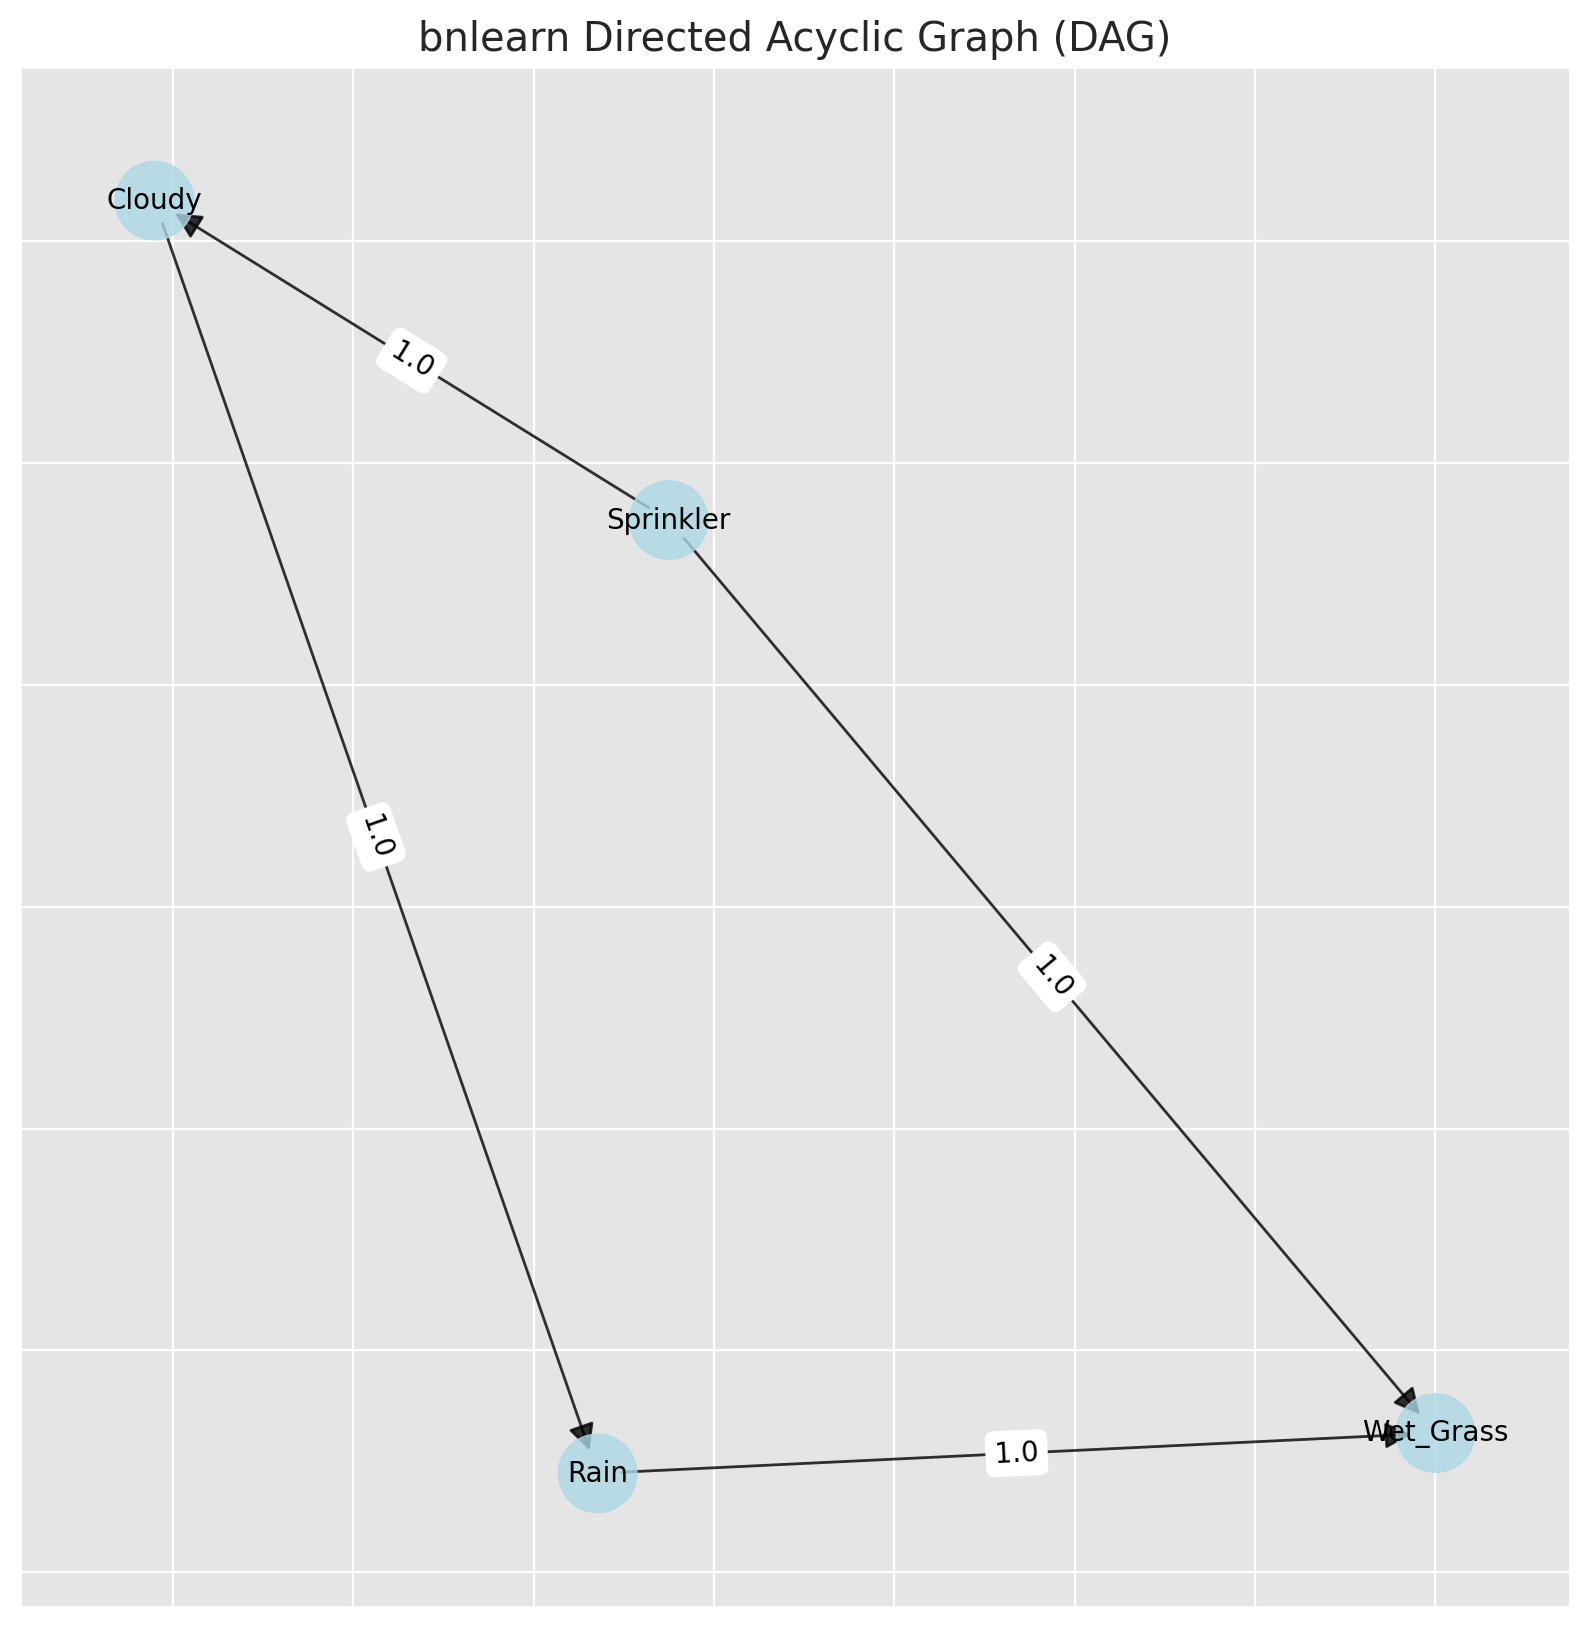

INFO:d3blocks.d3blocks:Cleaning edge_properties and config parameters..
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Converting source-target into adjacency matrix..
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Making the matrix symmetric..
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Set directed=True to see the markers!
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Keep only edges with weight>0
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Converting source-target into adjacency matrix..
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Making the matrix symmetric..
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Converting adjacency matrix into source-target..
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Number of unique nodes: %.0d
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Slider range is set to [0, 1]


[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.


[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Write to path: [/tmp/d3graph/d3graph.html]
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] File already exists and will be overwritten: [/tmp/d3graph/d3graph.html]
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Keep only edges with weight>0
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Converting source-target into adjacency matrix..
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Making the matrix symmetric..
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Number of unique nodes: %.0d
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Slider range is set to [0, 1]
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] Write to path: [/tmp/d3graph/bnlearn_Directed_Acyclic_Graph_(DAG).html]
[08-02-2026 11:41:37] [d3graph.d3graph] [INFO] File already exists and will be overwritten: [/tmp/d3graph/bnlearn_Directed_Acyclic_Graph_(DAG).html]
[08-02-2026 11:41:38] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the sys

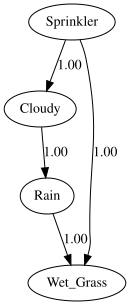

In [7]:
# Learn the DAG in data using Bayesian structure learning:
DAG = bn.structure_learning.fit(sprinkler_df)

# print adjacency matrix
display(DAG['adjmat'])

# Plot in Python
G = bn.plot(DAG)

# Make interactive plot in HTML
G = bn.plot(DAG, interactive=True)

# Make PDF plot
bn.plot_graphviz(DAG)

In [8]:
# 'hc' or 'hillclimbsearch'
model_hc_bic  = bn.structure_learning.fit(sprinkler_df, methodtype='hc', scoretype='bic')
model_hc_k2   = bn.structure_learning.fit(sprinkler_df, methodtype='hc', scoretype='k2')
model_hc_bdeu = bn.structure_learning.fit(sprinkler_df, methodtype='hc', scoretype='bdeu')

# 'ex' or 'exhaustivesearch'
model_ex_bic  = bn.structure_learning.fit(sprinkler_df, methodtype='ex', scoretype='bic')
model_ex_k2   = bn.structure_learning.fit(sprinkler_df, methodtype='ex', scoretype='k2')
model_ex_bdeu = bn.structure_learning.fit(sprinkler_df, methodtype='ex', scoretype='bdeu')

# 'cs' or 'constraintsearch'
model_cs_k2   = bn.structure_learning.fit(sprinkler_df, methodtype='cs', scoretype='k2')
model_cs_bdeu = bn.structure_learning.fit(sprinkler_df, methodtype='cs', scoretype='bdeu')
model_cs_bic  = bn.structure_learning.fit(sprinkler_df, methodtype='cs', scoretype='bic')

# 'cl' or 'chow-liu' (requires setting root_node parameter)
model_cl      = bn.structure_learning.fit(sprinkler_df, methodtype='cl', root_node='Wet_Grass')

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [k2]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bdeu]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Computing best DAG using [ex]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Computing best DAG using [ex]
[bnlearn] >Set scoring type at [k2]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Computing best DAG using [ex]
[bnlearn] >Set scoring type at [bdeu]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Computing best DAG using [cs]
[bnlearn] >Build skeleton wit

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Warning: Structure scoring could not be computed. Method [cs] not supported.
[bnlearn] >Computing best DAG using [cs]
[bnlearn] >Build skeleton with [chi_square] and alpha=0.05


  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Warning: Structure scoring could not be computed. Method [cs] not supported.
[bnlearn] >Computing best DAG using [chow-liu]


Building tree:   0%|          | 0/6.0 [00:00<?, ?it/s]

[bnlearn] >Compute structure scores for model comparison (higher is better).


Sprinkler dataset columns: Index(['Cloudy', 'Sprinkler', 'Rain', 'Wet_Grass'], dtype='object')
[bnlearn]> Auto generate placeholders for the CPTs.
[bnlearn] >CPT for Sprinkler:
+--------------+-----------+-----------+
| Cloudy       | Cloudy(0) | Cloudy(1) |
+--------------+-----------+-----------+
| Sprinkler(0) | 0.5       | 0.5       |
+--------------+-----------+-----------+
| Sprinkler(1) | 0.5       | 0.5       |
+--------------+-----------+-----------+
[bnlearn] >CPT for Rain:
+---------+-----------+-----------+
| Cloudy  | Cloudy(0) | Cloudy(1) |
+---------+-----------+-----------+
| Rain(0) | 0.5       | 0.5       |
+---------+-----------+-----------+
| Rain(1) | 0.5       | 0.5       |
+---------+-----------+-----------+
[bnlearn] >CPT for Wet_Grass:
+--------------+--------------+--------------+--------------+--------------+
| Sprinkler    | Sprinkler(0) | Sprinkler(0) | Sprinkler(1) | Sprinkler(1) |
+--------------+--------------+--------------+--------------+--------------

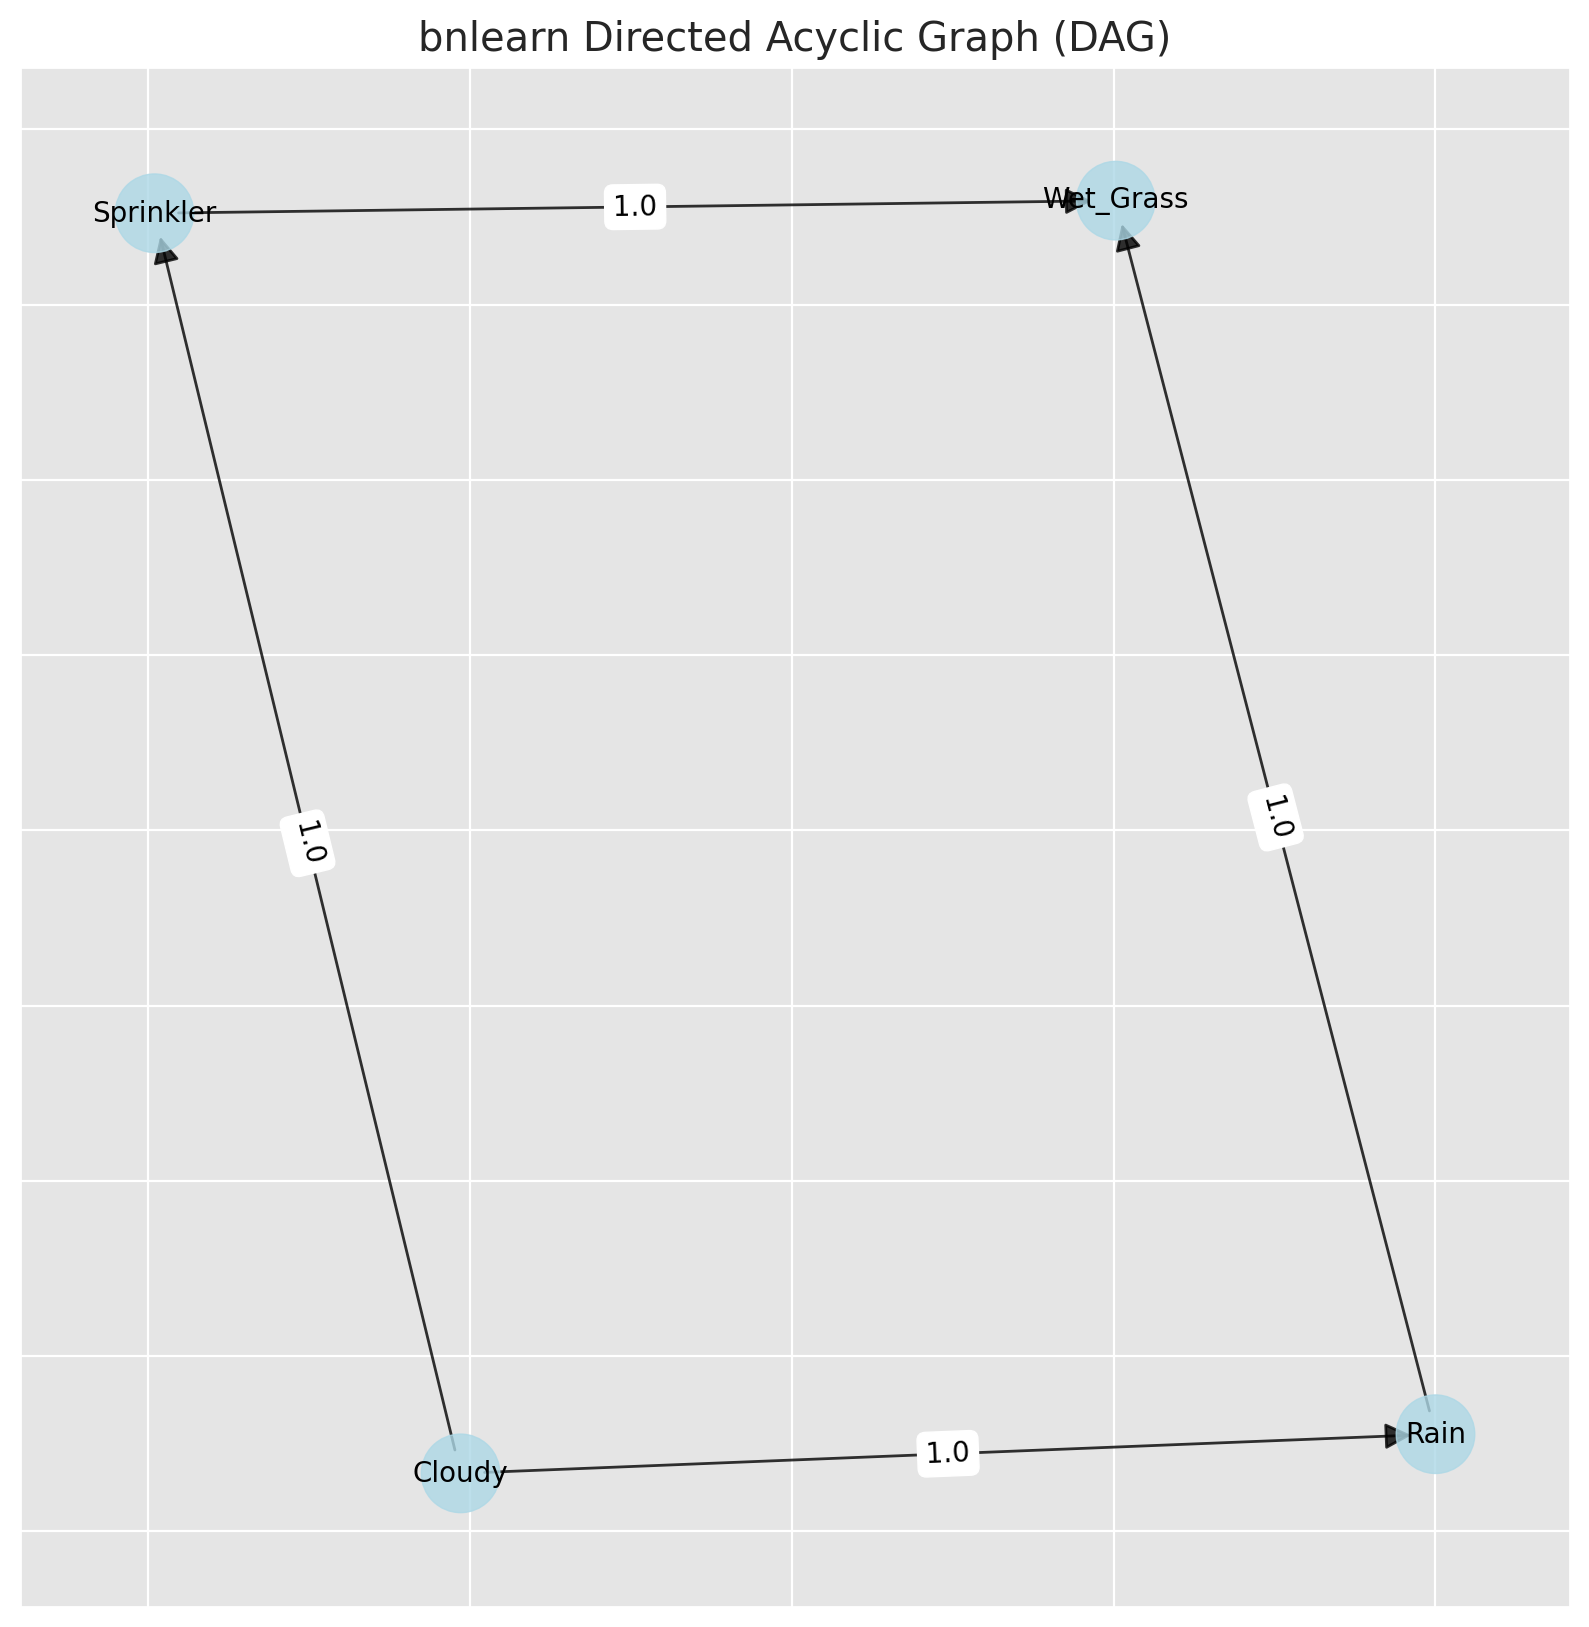

[bnlearn] >Parameter learning> Computing parameters using [ml]
[bnlearn] >CPD of Sprinkler:
+--------------+--------------------+------------+
| Cloudy       | Cloudy(0)          | Cloudy(1)  |
+--------------+--------------------+------------+
| Sprinkler(0) | 0.4610655737704918 | 0.91015625 |
+--------------+--------------------+------------+
| Sprinkler(1) | 0.5389344262295082 | 0.08984375 |
+--------------+--------------------+------------+
[bnlearn] >CPD of Rain:
+---------+---------------------+-------------+
| Cloudy  | Cloudy(0)           | Cloudy(1)   |
+---------+---------------------+-------------+
| Rain(0) | 0.8073770491803278  | 0.177734375 |
+---------+---------------------+-------------+
| Rain(1) | 0.19262295081967212 | 0.822265625 |
+---------+---------------------+-------------+
[bnlearn] >CPD of Wet_Grass:
+--------------+--------------+-----+----------------------+
| Rain         | Rain(0)      | ... | Rain(1)              |
+--------------+--------------+-----+---

{'Sprinkler':    Sprinkler  Cloudy         p
 0          0       0  0.461066
 1          0       1  0.910156
 2          1       0  0.538934
 3          1       1  0.089844,
 'Rain':    Rain  Cloudy         p
 0     0       0  0.807377
 1     0       1  0.177734
 2     1       0  0.192623
 3     1       1  0.822266,
 'Wet_Grass':    Wet_Grass  Rain  Sprinkler         p
 0          0     0          0  1.000000
 1          0     0          1  0.156250
 2          0     1          0  0.113953
 3          0     1          1  0.023529
 4          1     0          0  0.000000
 5          1     0          1  0.843750
 6          1     1          0  0.886047
 7          1     1          1  0.976471,
 'Cloudy':    Cloudy      p
 0       0  0.488
 1       1  0.512}

In [9]:
# The edges can be created using the available variables.
print(f"Sprinkler dataset columns: {sprinkler_df.columns}")

# Define the causal dependencies based on your expert/domain knowledge.
# Left is the source, and right is the target node.
edges = [('Cloudy', 'Sprinkler'),
         ('Cloudy', 'Rain'),
         ('Sprinkler', 'Wet_Grass'),
         ('Rain', 'Wet_Grass')]

# Create the DAG. If not CPTs are present, bnlearn will auto generate placeholders for the CPTs.
DAG = bn.make_DAG(edges)

# Plot the DAG. This is identical as shown in Figure 3
bn.plot(DAG)

# Parameter learning on the user-defined DAG and input data using maximumlikelihood
model = bn.parameter_learning.fit(DAG, sprinkler_df, methodtype='ml')

# Print the learned CPDs
bn.print_CPD(model)

In [10]:
# Compute CPT for the Cloudy Node:

# P(Cloudy=0)
p_cloudy0 = sum(sprinkler_df['Cloudy'] == 0) / sprinkler_df.shape[0]
print(f"P(Cloudy=0): {p_cloudy0}")

# P(Cloudy=1)
p_cloudy1 = sum(sprinkler_df['Cloudy']==1) / sprinkler_df.shape[0] # 0.512
print(f"P(Cloudy=1): {p_cloudy1}")

# Compute CPT for the Rain Node:

# P(Rain=0 | Cloudy=0)
p_rain0_cloudy0 = sum( (sprinkler_df['Cloudy']==0) & (sprinkler_df['Rain']==0) ) / sum(sprinkler_df['Cloudy']==0) # 394/488 = 0.807377049
print(f"P(Rain=0 | Cloudy=0): {p_rain0_cloudy0}")

# P(Rain=1 | Cloudy=0)
p_rain1_cloudy0 = sum( (sprinkler_df['Cloudy']==0) & (sprinkler_df['Rain']==1) ) / sum(sprinkler_df['Cloudy']==0) # 94/488  = 0.192622950
print(f"P(Rain=1 | Cloudy=0): {p_rain1_cloudy0}")

# P(Rain=0 | Cloudy=1)
p_rain0_cloudy1 = sum( (sprinkler_df['Cloudy']==1) & (sprinkler_df['Rain']==0) ) / sum(sprinkler_df['Cloudy']==1) # 91/512  = 0.177734375
print(f"P(Rain=0 | Cloudy=1): {p_rain0_cloudy1}")

# P(Rain=1 | Cloudy=1)
p_rain1_cloudy1 = sum( (sprinkler_df['Cloudy']==1) & (sprinkler_df['Rain']==1) ) / sum(sprinkler_df['Cloudy']==1) # 421/512 = 0.822265625
print(f"P(Rain=1 | Cloudy=1): {p_rain1_cloudy1}")

P(Cloudy=0): 0.488
P(Cloudy=1): 0.512
P(Rain=0 | Cloudy=0): 0.8073770491803278
P(Rain=1 | Cloudy=0): 0.19262295081967212
P(Rain=0 | Cloudy=1): 0.177734375
P(Rain=1 | Cloudy=1): 0.822265625


In [11]:
# Define the causal dependencies based on your expert/domain knowledge.
# Left is the source, and right is the target node.
edges = [('Cloudy', 'Sprinkler'),
         ('Cloudy', 'Rain'),
         ('Sprinkler', 'Wet_Grass'),
         ('Rain', 'Wet_Grass')]

# Create the DAG
DAG = bn.make_DAG(edges)

# Parameter learning on the user-defined DAG and input data using Bayes to estimate the CPTs
model = bn.parameter_learning.fit(DAG, sprinkler_df, methodtype='bayes')
bn.print_CPD(model)

[bnlearn]> Auto generate placeholders for the CPTs.
[bnlearn] >CPT for Sprinkler:
+--------------+-----------+-----------+
| Cloudy       | Cloudy(0) | Cloudy(1) |
+--------------+-----------+-----------+
| Sprinkler(0) | 0.5       | 0.5       |
+--------------+-----------+-----------+
| Sprinkler(1) | 0.5       | 0.5       |
+--------------+-----------+-----------+
[bnlearn] >CPT for Rain:
+---------+-----------+-----------+
| Cloudy  | Cloudy(0) | Cloudy(1) |
+---------+-----------+-----------+
| Rain(0) | 0.5       | 0.5       |
+---------+-----------+-----------+
| Rain(1) | 0.5       | 0.5       |
+---------+-----------+-----------+
[bnlearn] >CPT for Wet_Grass:
+--------------+--------------+--------------+--------------+--------------+
| Sprinkler    | Sprinkler(0) | Sprinkler(0) | Sprinkler(1) | Sprinkler(1) |
+--------------+--------------+--------------+--------------+--------------+
| Rain         | Rain(0)      | Rain(1)      | Rain(0)      | Rain(1)      |
+--------------+

[bnlearn] >CPD of Sprinkler:
+--------------+--------------------+--------------------+
| Cloudy       | Cloudy(0)          | Cloudy(1)          |
+--------------+--------------------+--------------------+
| Sprinkler(0) | 0.4807692307692308 | 0.7075098814229249 |
+--------------+--------------------+--------------------+
| Sprinkler(1) | 0.5192307692307693 | 0.2924901185770751 |
+--------------+--------------------+--------------------+
[bnlearn] >CPD of Rain:
+---------+--------------------+---------------------+
| Cloudy  | Cloudy(0)          | Cloudy(1)           |
+---------+--------------------+---------------------+
| Rain(0) | 0.6518218623481782 | 0.33695652173913043 |
+---------+--------------------+---------------------+
| Rain(1) | 0.3481781376518219 | 0.6630434782608695  |
+---------+--------------------+---------------------+
[bnlearn] >CPD of Wet_Grass:
+--------------+--------------------+-----+---------------------+
| Rain         | Rain(0)            | ... | Rain(1)   

{'Sprinkler':    Sprinkler  Cloudy         p
 0          0       0  0.480769
 1          0       1  0.707510
 2          1       0  0.519231
 3          1       1  0.292490,
 'Rain':    Rain  Cloudy         p
 0     0       0  0.651822
 1     0       1  0.336957
 2     1       0  0.348178
 3     1       1  0.663043,
 'Wet_Grass':    Wet_Grass  Rain  Sprinkler         p
 0          0     0          0  0.755382
 1          0     0          1  0.337553
 2          0     1          0  0.255882
 3          0     1          1  0.379104
 4          1     0          0  0.244618
 5          1     0          1  0.662447
 6          1     1          0  0.744118
 7          1     1          1  0.620896,
 'Cloudy':    Cloudy      p
 0       0  0.494
 1       1  0.506}

In [12]:
q1 = bn.inference.fit(model, variables=['Wet_Grass'], evidence={'Sprinkler':0})

[bnlearn] >Variable Elimination.
+----+-------------+----------+
|    |   Wet_Grass |        p |
+====+=============+==========+
|  0 |           0 | 0.486917 |
+----+-------------+----------+
|  1 |           1 | 0.513083 |
+----+-------------+----------+

Summary for variables: ['Wet_Grass']
Given evidence: Sprinkler=0

Wet_Grass outcomes:
- Wet_Grass: 0 (48.7%)
- Wet_Grass: 1 (51.3%)


In [13]:
q2 = bn.inference.fit(model, variables=['Rain'], evidence={'Sprinkler':0, 'Cloudy':1})

[bnlearn] >Variable Elimination.
+----+--------+----------+
|    |   Rain |        p |
+====+========+==========+
|  0 |      0 | 0.336957 |
+----+--------+----------+
|  1 |      1 | 0.663043 |
+----+--------+----------+

Summary for variables: ['Rain']
Given evidence: Sprinkler=0, Cloudy=1

Rain outcomes:
- Rain: 0 (33.7%)
- Rain: 1 (66.3%)


In [14]:
q3 = bn.inference.fit(model, variables=['Wet_Grass','Rain'], evidence={'Sprinkler':1})

[bnlearn] >Variable Elimination.
+----+-------------+--------+----------+
|    |   Wet_Grass |   Rain |        p |
+====+=============+========+==========+
|  0 |           0 |      0 | 0.181137 |
+----+-------------+--------+----------+
|  1 |           0 |      1 | 0.17567  |
+----+-------------+--------+----------+
|  2 |           1 |      0 | 0.355481 |
+----+-------------+--------+----------+
|  3 |           1 |      1 | 0.287712 |
+----+-------------+--------+----------+

Summary for variables: ['Wet_Grass', 'Rain']
Given evidence: Sprinkler=1

Wet_Grass outcomes:
- Wet_Grass: 0 (35.7%)
- Wet_Grass: 1 (64.3%)

Rain outcomes:
- Rain: 0 (53.7%)
- Rain: 1 (46.3%)


In [15]:
# Function to check if a graph is acyclic.
def is_acyclic(graph, n):
    visited = [False] * n
    rec_stack = [False] * n
    def visit(v):
        if rec_stack[v]:
            return False  # Found a cycle
        if visited[v]:
            return True  # Already visited
        visited[v] = True
        rec_stack[v] = True
        for u in range(n):
            if graph[v][u] and not visit(u):
                return False
        rec_stack[v] = False
        return True
    return all(visit(v) for v in range(n) if not visited[v])

# Number of variables (nodes)
n = 4

# Generate all possible directed edges between the 4 variables
nodes = range(n)
edges = list(itertools.permutations(nodes, 2))  # All possible ordered pairs of nodes
total_graphs = 0

# Check all subsets of edges (2^number of possible edges)
for subset in itertools.product([0, 1], repeat=len(edges)):
    # Create the graph from the subset
    graph = [[0] * n for _ in range(n)]
    for i, (u, v) in enumerate(edges):
        if subset[i]:
            graph[u][v] = 1  # Add a directed edge
    # Check if the graph is acyclic
    if is_acyclic(graph, n):
        total_graphs += 1  # Count the acyclic graphs

# Output the total number of acyclic graphs (DAGs)
print(f"Total number of possible DAGs for {n} variables: {total_graphs}")

Total number of possible DAGs for 4 variables: 543


[bnlearn] >Computing best DAG using [exhaustivesearch]
[bnlearn] >Set scoring type at [bic]


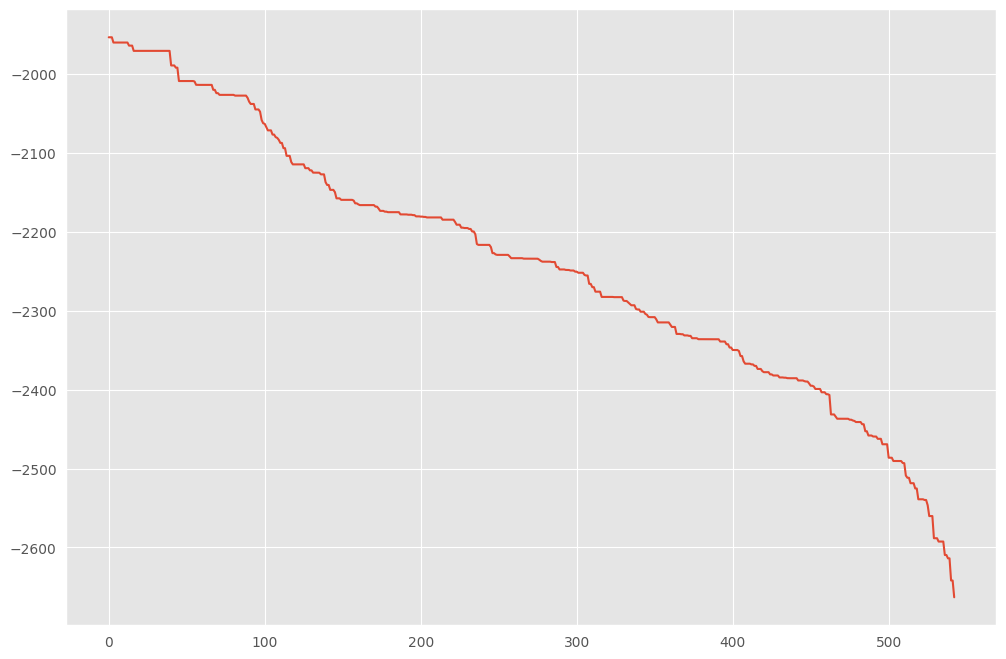

[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Compute edge strength with [chi_square]


target,Cloudy,Rain,Sprinkler,Wet_Grass
source,,,,
Cloudy,False,True,True,False
Rain,False,False,False,True
Sprinkler,False,False,False,True
Wet_Grass,False,False,False,False


In [16]:
# Learn the DAG in data using Bayesian structure learning and return all possible DAGs:
model = bn.structure_learning.fit(sprinkler_df, methodtype='exhaustivesearch', scoretype='bic', return_all_dags=True)

# Compute edge weights using ChiSquare independence test.
model = bn.independence_test(model, sprinkler_df, test='chi_square', prune=False)

# print adjacency matrix
display(model['adjmat'])

[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [chi_square] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


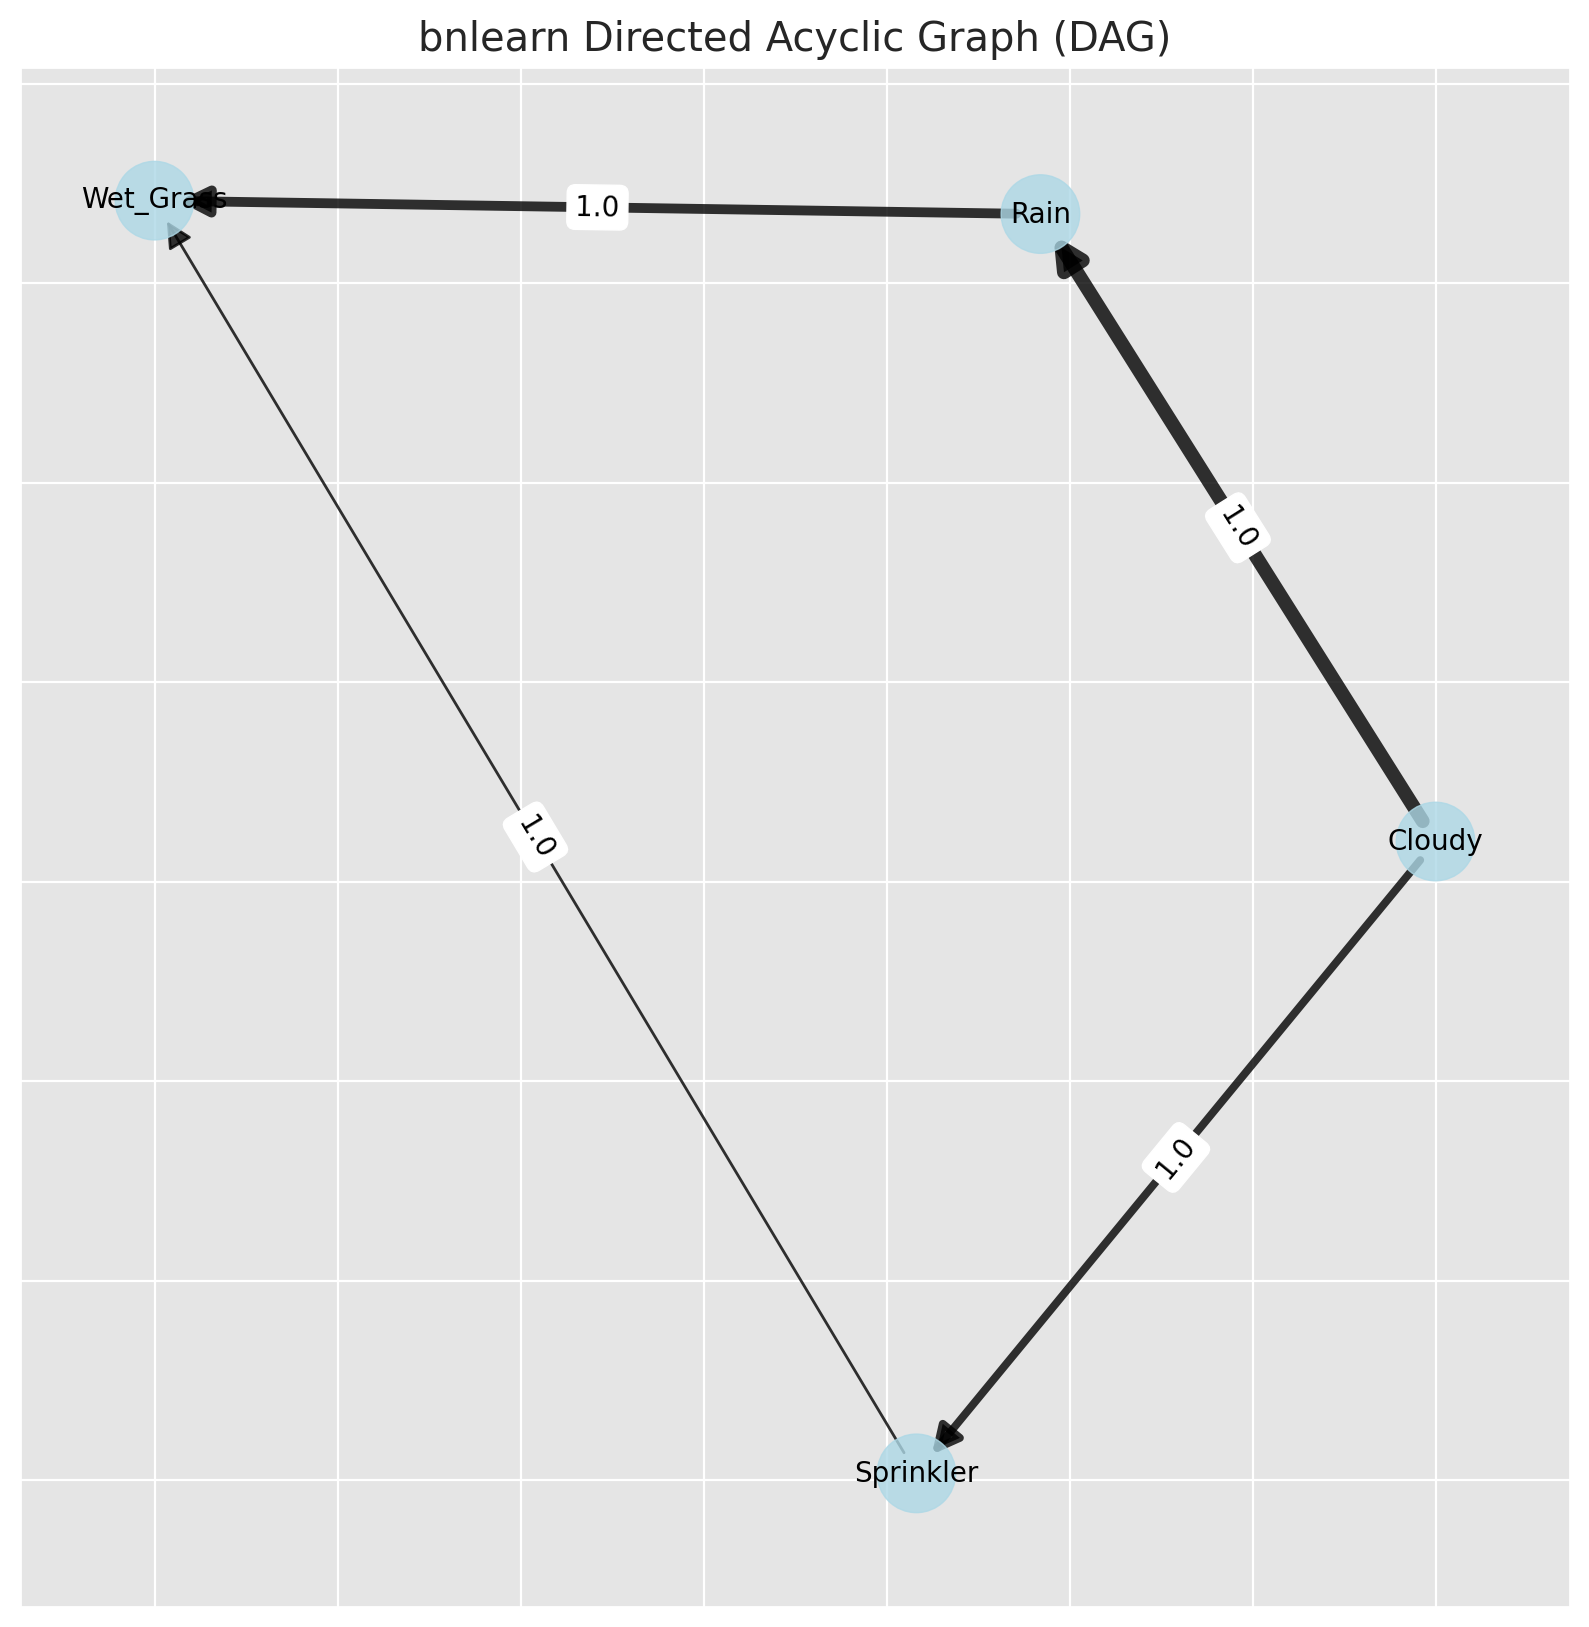

[08-02-2026 11:44:45] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 11:44:45] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 11:44:45] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.
[08-02-2026 11:44:45] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.


In [17]:
# Plot the best DAG
G = bn.plot(model, interactive=False)

# Plot using graphiviz
dot = bn.plot_graphviz(model)

[bnlearn] >Computing best DAG using [hillclimbsearch]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Compute edge strength with [chi_square]
[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [chi_square] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


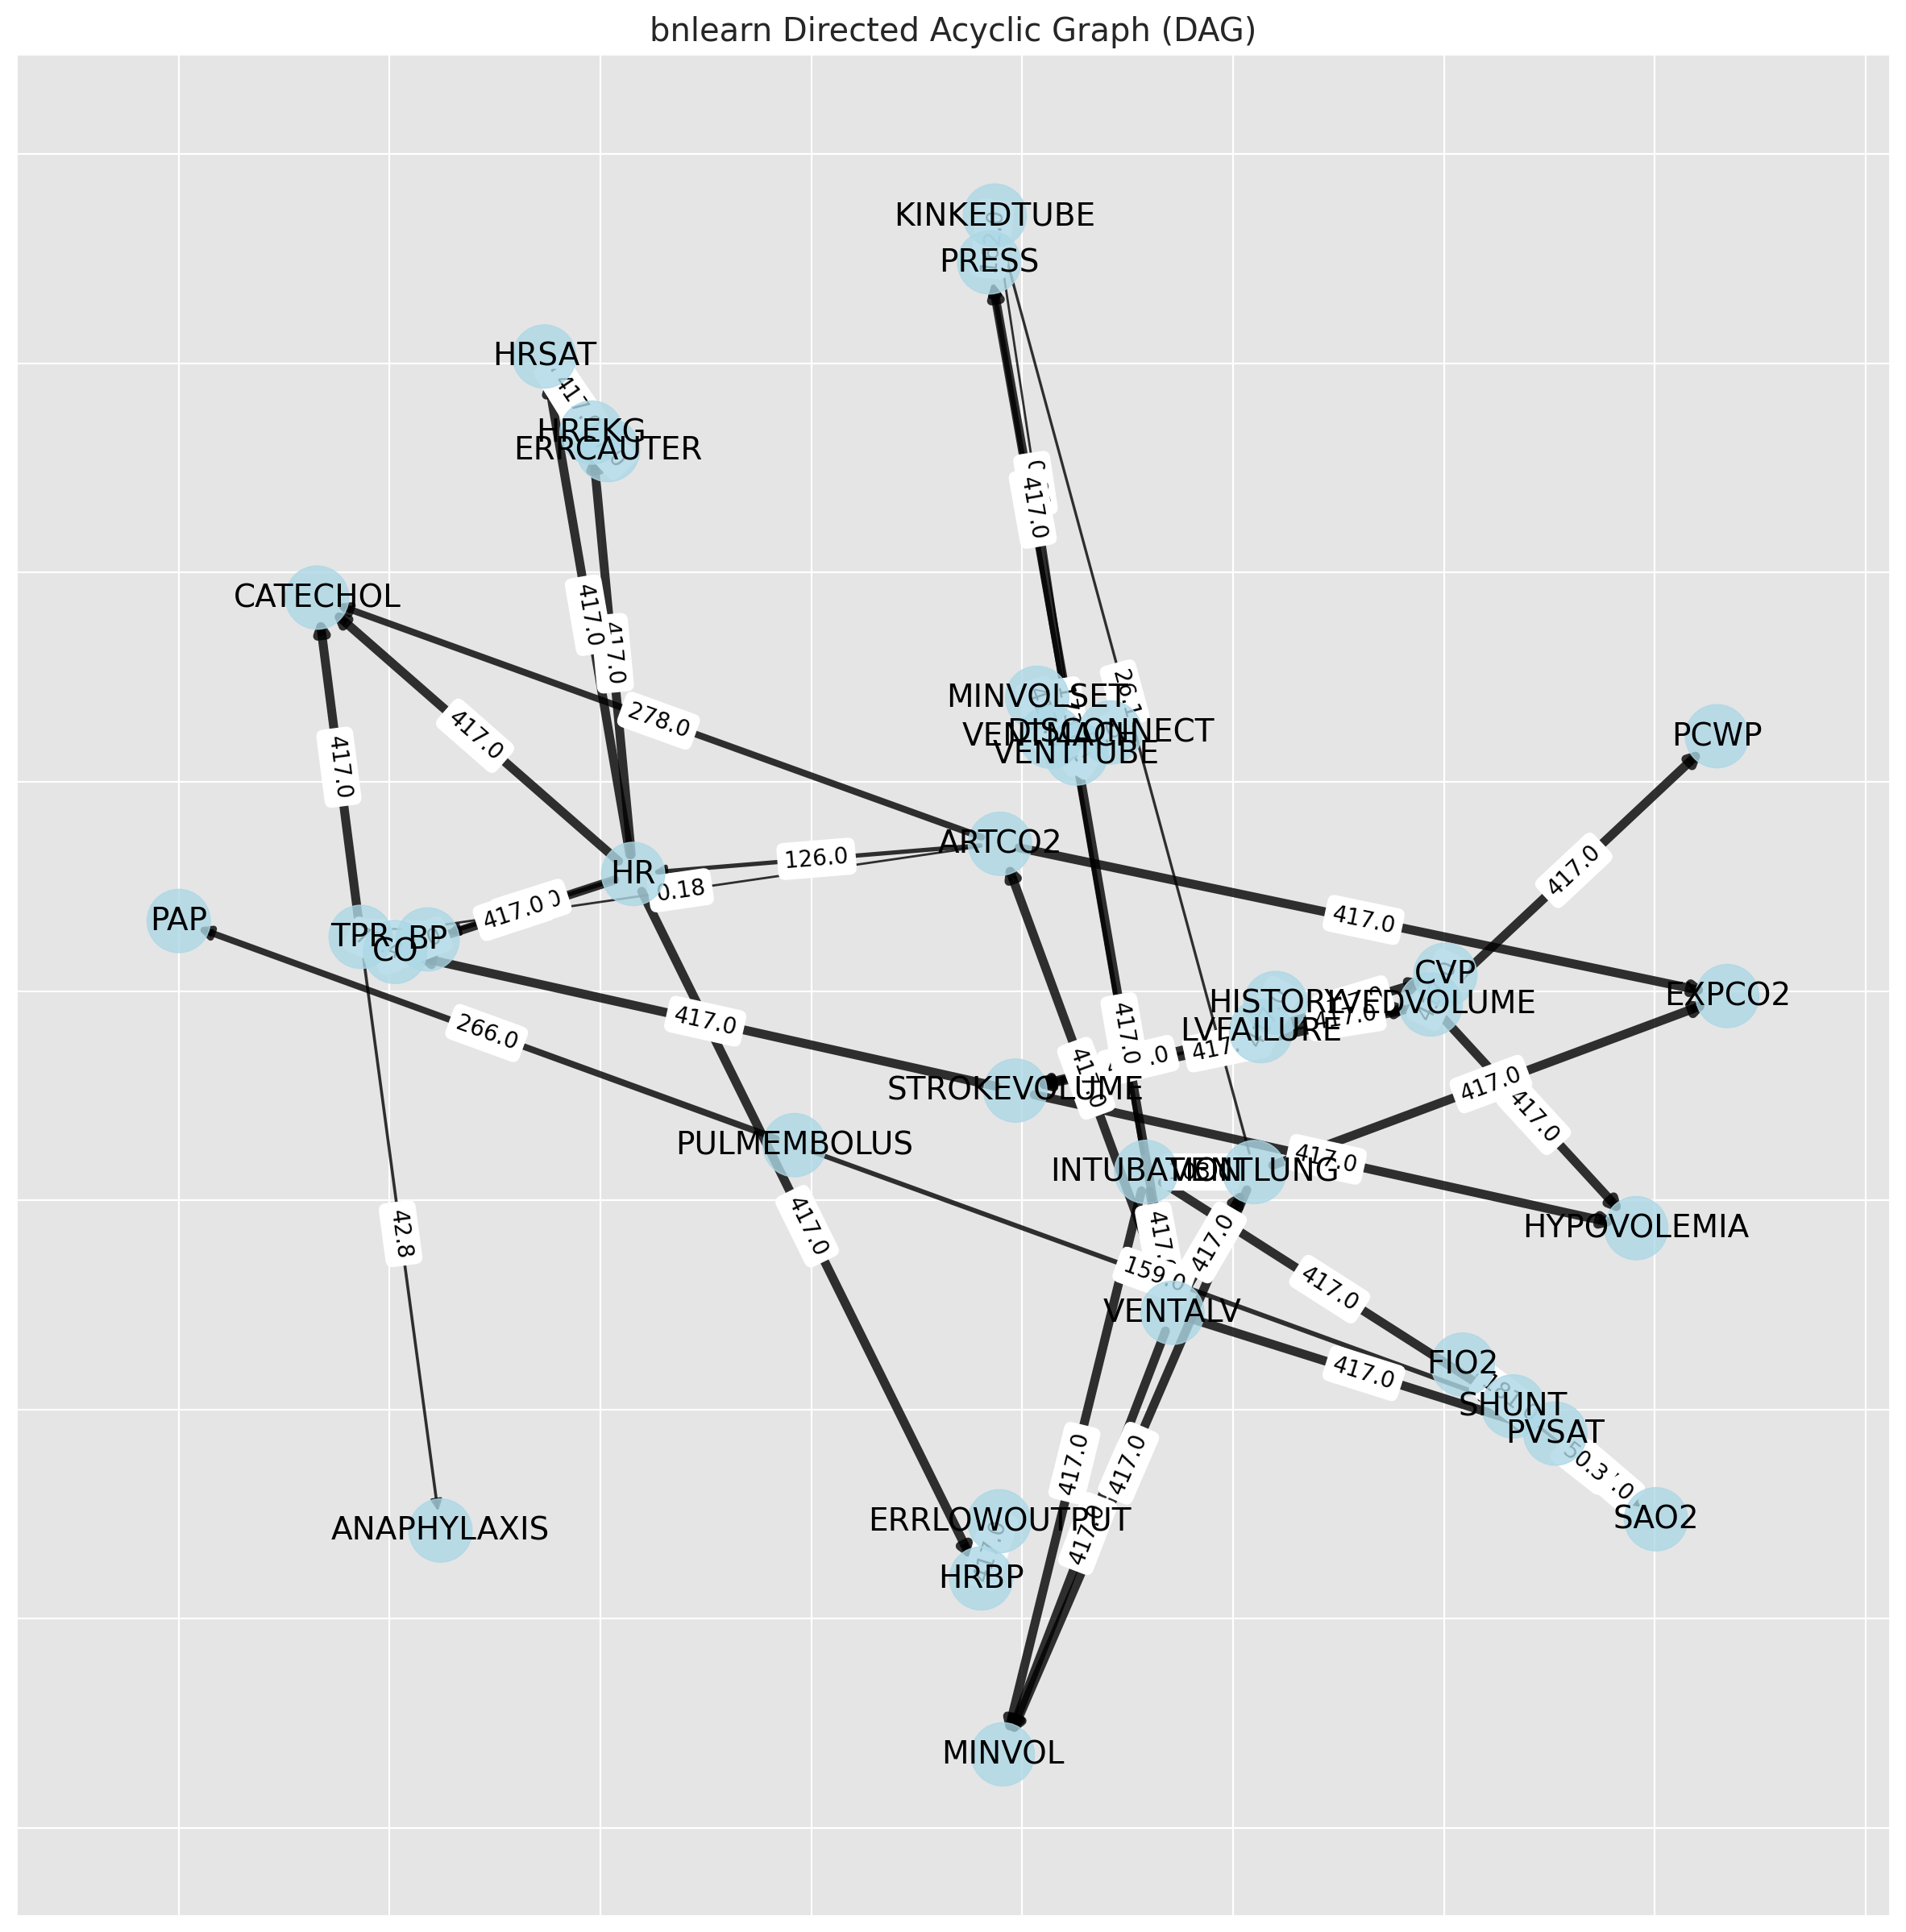

[08-02-2026 11:45:56] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 11:45:56] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[08-02-2026 11:45:56] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.
[08-02-2026 11:45:56] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.


'bnlearn_alarm.pdf'

In [18]:
# Load Alarm dataset
alarm_df = bn.import_example('alarm')

# Learn the DAG in data using hillclimbsearch and BIC
model = bn.structure_learning.fit(alarm_df, methodtype='hillclimbsearch', scoretype='bic')

# Compute edge weights using ChiSquare independence test.
model = bn.independence_test(model, alarm_df, test='chi_square', prune=False)

# Plot the best DAG
bn.plot(model, edge_labels='pvalue', params_static={'maxscale': 4, 'figsize': (15, 15), 'font_size': 14, 'arrowsize': 10})

# Plot using graphiviz
dot = bn.plot_graphviz(model)

# Store to pdf
# dot.render(filename='bnlearn_alarm')

# View in browser
dot.view(filename='bnlearn_alarm')

In [19]:
from google.colab import files
files.download('bnlearn_alarm.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>